In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, classification_report

In [69]:
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

### Загрузка датфрейма и анализ

In [70]:
df = pd.read_csv('dataset.csv', sep=',')
df

,id,наименование_задачи,тип_задачи,технологический_стек,срок_выполнения_дней,цена_руб,ценовой_диапазон
0,1,Синхронизация CRM и 1С,Автоматизация и скрипты,Zapier+Python,14,7000,5 000–15 000 ₽
1,2,Приложение учёта финансов,Мобильное приложение,Flutter,31,33200,30 000–60 000 ₽
2,3,Приложение трекинга тренировок,Мобильное приложение,React Native+Redux,10,70000,60 000–120 000 ₽
3,4,Вёрстка личного кабинета,Вёрстка,HTML+CSS+BEM,12,3500,до 5 000 ₽
4,5,Каталог с корзиной на Flutter,Мобильное приложение,React Native+TS,40,69000,60 000–120 000 ₽
...,...,...,...,...,...,...,...
2995,2996,Каталог с корзиной на Flutter,Мобильное приложение,Kotlin (Android),40,62100,60 000–120 000 ₽
2996,2997,Клиентское приложение для барбершопа,Мобильное приложение,Flutter+Firebase,21,24000,15 000–30 000 ₽
2997,2998,Лендинг для агентства недвижимости,Лендинг,Vue.js,11,14000,5 000–15 000 ₽
2998,2999,Дизайн-система и UI-кит,UI/UX Дизайн,Sketch,3,15000,15 000–30 000 ₽


In [71]:
df.shape

(3000, 7)

In [72]:
df.dtypes

id                       int64
наименование_задачи     object
тип_задачи              object
технологический_стек    object
срок_выполнения_дней     int64
цена_руб                 int64
ценовой_диапазон        object
dtype: object

In [73]:
df.head()

,id,наименование_задачи,тип_задачи,технологический_стек,срок_выполнения_дней,цена_руб,ценовой_диапазон
0,1,Синхронизация CRM и 1С,Автоматизация и скрипты,Zapier+Python,14,7000,5 000–15 000 ₽
1,2,Приложение учёта финансов,Мобильное приложение,Flutter,31,33200,30 000–60 000 ₽
2,3,Приложение трекинга тренировок,Мобильное приложение,React Native+Redux,10,70000,60 000–120 000 ₽
3,4,Вёрстка личного кабинета,Вёрстка,HTML+CSS+BEM,12,3500,до 5 000 ₽
4,5,Каталог с корзиной на Flutter,Мобильное приложение,React Native+TS,40,69000,60 000–120 000 ₽


In [74]:
df.isna().sum()

id                      0
наименование_задачи     0
тип_задачи              0
технологический_стек    0
срок_выполнения_дней    0
цена_руб                0
ценовой_диапазон        0
dtype: int64

In [75]:
df['цена_руб'].describe()

count      3000.000000
mean      18362.000000
std       20184.316309
min        2000.000000
25%        6000.000000
50%       10000.000000
75%       20725.000000
max      136500.000000
Name: цена_руб, dtype: float64

In [76]:
df['ценовой_диапазон'].value_counts()

ценовой_диапазон
5 000–15 000 ₽      1560
15 000–30 000 ₽      535
до 5 000 ₽           382
30 000–60 000 ₽      323
60 000–120 000 ₽     197
свыше 120 000 ₽        3
Name: count, dtype: int64

In [77]:
df.columns

Index(['id', 'наименование_задачи', 'тип_задачи', 'технологический_стек',
       'срок_выполнения_дней', 'цена_руб', 'ценовой_диапазон'],
      dtype='object')

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    3000 non-null   int64 
 1   наименование_задачи   3000 non-null   object
 2   тип_задачи            3000 non-null   object
 3   технологический_стек  3000 non-null   object
 4   срок_выполнения_дней  3000 non-null   int64 
 5   цена_руб              3000 non-null   int64 
 6   ценовой_диапазон      3000 non-null   object
dtypes: int64(3), object(4)
memory usage: 164.2+ KB


По первичному анализу видно, что цена распределена неравномерно, пропусков нет, наблюдается дисбаланс классов.

### EDA

In [79]:
df['log_цена'] = np.log(df['цена_руб'])

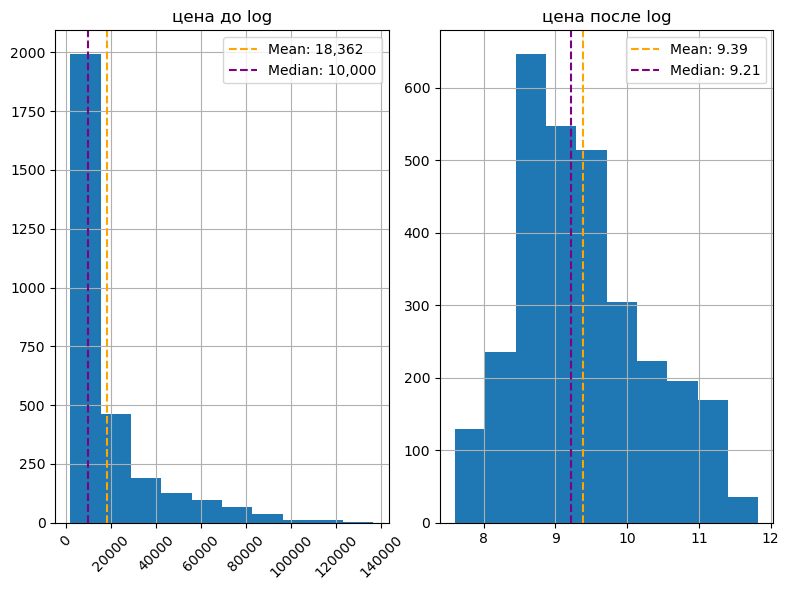

In [80]:
fig, axs = plt.subplots(1, 2, figsize=(8, 6))

df['цена_руб'].hist(ax=axs[0])
axs[0].axvline(df['цена_руб'].mean(), color='orange', linestyle='--',
                label=f'Mean: {df['цена_руб'].mean():,.0f}')
axs[0].axvline(df['цена_руб'].median(), color='purple', linestyle='--',
                label=f'Median: {df['цена_руб'].median():,.0f}')
axs[0].set_title('цена до log')
axs[0].legend()
axs[0].xaxis.set_tick_params(rotation=45)

df['log_цена'].hist(ax=axs[1])
axs[1].axvline(df['log_цена'].mean(), color='orange', linestyle='--',
                label=f'Mean: {df['log_цена'].mean():,.2f}')
axs[1].axvline(df['log_цена'].median(), color='purple', linestyle='--',
                label=f'Median: {df['log_цена'].median():,.2f}')
axs[1].set_title('цена после log')
axs[1].legend()

plt.tight_layout()
plt.show()

**До log-трансформации:**
Распределение сильно скошено вправо — mean (18 362 руб) почти в 2 раза больше median (10 000 руб). 
Это означает что большинство задач стоят около 10 000 ₽, но есть дорогие выбросы, которые тянут среднее вверх. 
Такое распределение плохо подходит для ML-моделей.

**После log-трансформации:**
Log сжимает большие значения и растягивает маленькие — разброс выравнивается.
Распределение приобретает форму близкую к нормальному. 
Это улучшает качество обучения моделей, особенно линейной регрессии.

**Вывод:**
Log-трансформация устраняет влияние выбросов и делает данные пригодными для регрессии.

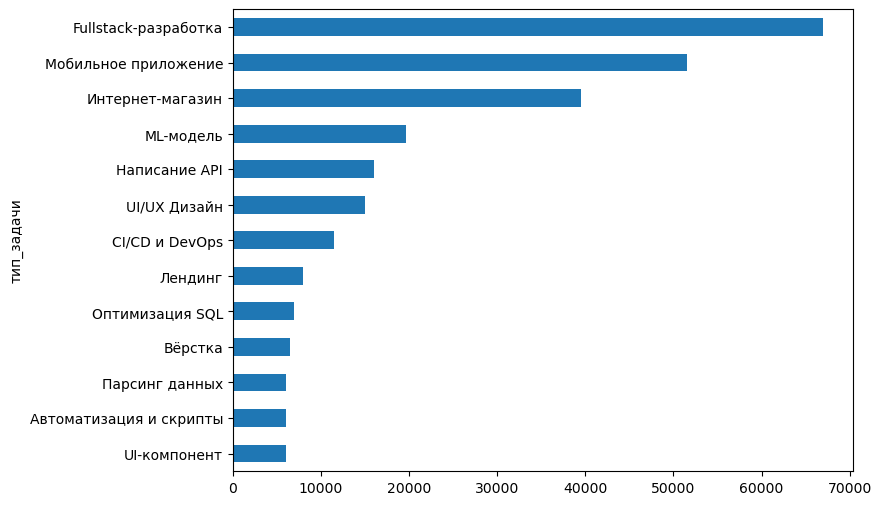

In [81]:
plt.figure(figsize=(8, 6))
df.groupby('тип_задачи')['цена_руб'].median().sort_values().plot(kind='barh')

plt.show()

На графике видно три группы:

**Дорогие задачи** — Fullstack-разработка (~67 000 ₽), Мобильное приложение (~52 000 ₽), Интернет-магазин (~40 000 ₽).
**Средние задачи** — ML-модель, Написание API, UI/UX Дизайн, CI/CD и DevOps (12 000–20 000 ₽).
**Дешёвые задачи** — Вёрстка, Лендинг, Парсинг, Автоматизация, UI-компонент (5 000–8 000 ₽).


**Вывод:** тип задачи — один из ключевых факторов ценообразования.

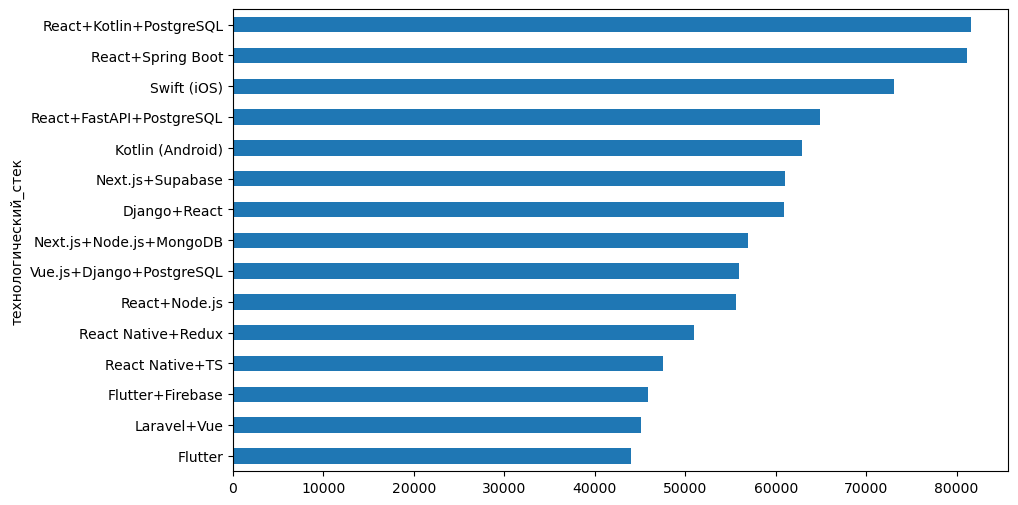

In [82]:
(df.groupby('технологический_стек')['цена_руб']
   .mean()
   .sort_values(ascending=False)
   .head(15)
   .sort_values()
   .plot(kind='barh', figsize=(10, 6)))

plt.show()

Цена стека определяется не только количеством технологий, 
но и их специализацией. Swift (iOS) и Kotlin (Android) — одиночные технологии, 
но входят в топ по цене.

Задачи с большим числом технологий в стеке, как правило, сложнее, поэтому 
был добавлен признак `размер_стека` как дополнительный сигнал, так как 
в среднем комбинированные стеки стоят дороже одиночных. 


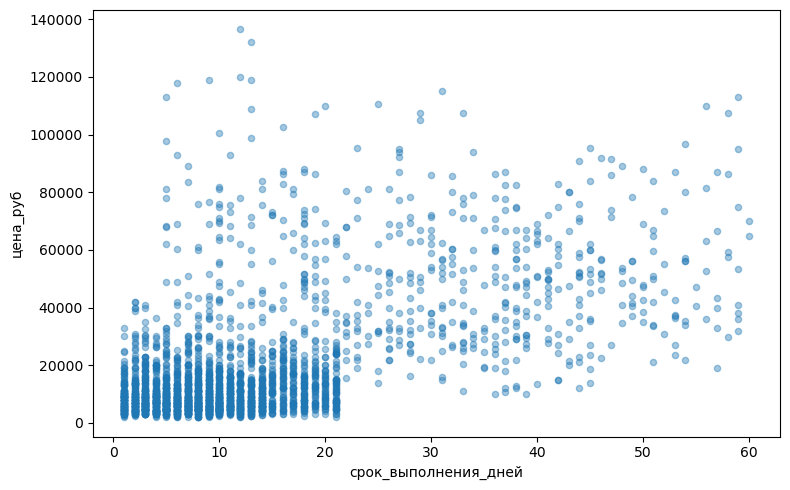

In [83]:
df.plot(kind='scatter', x='срок_выполнения_дней', y='цена_руб', alpha=0.4, 
        figsize=(8, 5))

plt.tight_layout()
plt.show()

На scatter-plot видно что большинство задач сосредоточены в диапазоне до 20 дней 
и стоят относительно дёшево. Задач с большим сроком значительно меньше, 
но среди них встречаются как дешёвые так и дорогие — чёткого тренда нет.

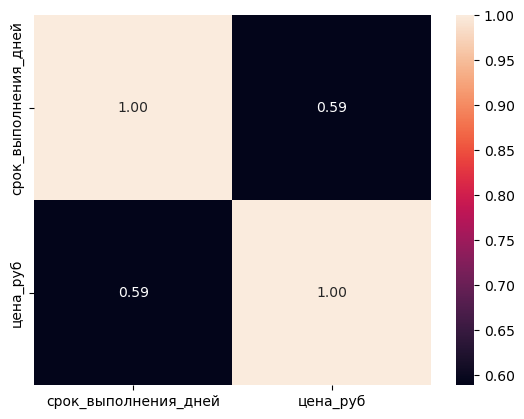

In [84]:
sns.heatmap(df[['срок_выполнения_дней', 'цена_руб']].corr(), 
            annot=True, 
            fmt='.2f')
plt.show()

Коэффициент 0.59 — умеренная связь. 
Срок влияет на цену, но не определяет её полностью — важны также тип задачи и стек.

По результатам графиков можно предположить, что важными признаками будут стек и тип задачи.

### Feature engineering

In [85]:
df_copy = df.copy()

Удаляем следующие признаки:
- `id` — порядковый номер, не несёт смысловой нагрузки
- `наименование_задачи` — свободный текст, требует NLP-обработки, выходит за рамки задачи
- `цена_руб` — целевая переменная для регрессии, заменяется на `log_цена` 

In [86]:
df_copy = df_copy.drop(['id', 'наименование_задачи', 'цена_руб'], axis=1)
df_copy.head()

,тип_задачи,технологический_стек,срок_выполнения_дней,ценовой_диапазон,log_цена
0,Автоматизация и скрипты,Zapier+Python,14,5 000–15 000 ₽,8.853665
1,Мобильное приложение,Flutter,31,30 000–60 000 ₽,10.410305
2,Мобильное приложение,React Native+Redux,10,60 000–120 000 ₽,11.156251
3,Вёрстка,HTML+CSS+BEM,12,до 5 000 ₽,8.160518
4,Мобильное приложение,React Native+TS,40,60 000–120 000 ₽,11.141862


Кодируем `тип_задачи` с помощью `pd.get_dummies` — категориальный признак без порядка, поэтому применяем One-Hot Encoding.

In [87]:
df_copy = pd.get_dummies(df_copy, columns=['тип_задачи'], drop_first=True, dtype=int)

Добавляем признак `размер_стека` — количество технологий в стеке, так как задачи с большим числом инструментов, как правило, сложнее.

In [88]:
df_copy['размер_стека'] = df_copy['технологический_стек'].str.split('+').str.len()

Смотрим частоту встречаемости каждой технологии в датасете, чтобы отобрать наиболее популярные для создания бинарных признаков.

In [89]:
df_copy['технологический_стек'].str.split('+').explode().value_counts()

технологический_стек
React           394
HTML            376
Python          307
CSS             228
Vue.js          218
               ... 
ClickHouse       17
scikit-learn     17
MongoDB          16
Zapier           15
Supabase          9
Name: count, Length: 82, dtype: int64

Создаём бинарные признаки для топ-15 наиболее часто встречаемых технологий — 1 если технология присутствует в стеке, 0 если нет.

In [90]:
top_tech = ['React', 'HTML', 'Python', 'CSS', 'Vue.js', 'Next.js', 
            'Figma', 'PostgreSQL', 'Tailwind', 'Node.js', 
            'React Native', 'Flutter', 'TypeScript', 'CSS Modules', 'JS']

for tech in top_tech:
    df_copy[f'стек_{tech}'] = df_copy['технологический_стек'].str.contains(tech, regex=False).astype(int)

df_copy.drop(columns=['технологический_стек'], inplace=True)

Объединяем классы "свыше 120 000 ₽" и "60 000–120 000 ₽" в один — мало данных для отдельного класса.
Кодируем `ценовой_диапазон` вручную через `map`, присваивая каждому диапазону число от 0 до 4 в порядке возрастания цены.

In [91]:
df_copy['ценовой_диапазон'] = df_copy['ценовой_диапазон'].replace('свыше 120 000 ₽', '60 000–120 000 ₽')

In [92]:
order = ['до 5 000 ₽', '5 000–15 000 ₽', '15 000–30 000 ₽', '30 000–60 000 ₽', '60 000–120 000 ₽']

df_copy['ценовой_диапазон'] = df_copy['ценовой_диапазон'].map({v: i for i, v in enumerate(order)})

In [93]:
df_copy.head()

,срок_выполнения_дней,ценовой_диапазон,log_цена,тип_задачи_Fullstack-разработка,тип_задачи_ML-модель,тип_задачи_UI-компонент,тип_задачи_UI/UX Дизайн,тип_задачи_Автоматизация и скрипты,тип_задачи_Вёрстка,тип_задачи_Интернет-магазин,...,стек_Next.js,стек_Figma,стек_PostgreSQL,стек_Tailwind,стек_Node.js,стек_React Native,стек_Flutter,стек_TypeScript,стек_CSS Modules,стек_JS
0,14,1,8.853665,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,31,3,10.410305,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,10,4,11.156251,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,12,0,8.160518,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,40,4,11.141862,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


### Models

#### Регрессия

In [94]:
X = df_copy.drop(['ценовой_диапазон', 'log_цена'], axis=1)
y = df_copy['log_цена']

Добавляем признак `стек_средняя_цена` — средняя log-цена задач с данным стеком, посчитанная только на обучающей выборке. Это позволяет модели учитывать ценовой уровень каждого стека без утечки данных из тестовой выборки.

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

stack_mean = y_train.groupby(df.loc[X_train.index, 'технологический_стек']).mean()

X_train['стек_средняя_цена'] = df.loc[X_train.index, 'технологический_стек'].map(
    stack_mean)
X_test['стек_средняя_цена'] = df.loc[X_test.index, 'технологический_стек'].map(
    stack_mean)

X_train['стек_средняя_цена'] = X_train['стек_средняя_цена'].fillna(
    y_train.mean())
X_test['стек_средняя_цена'] = X_test['стек_средняя_цена'].fillna(
    y_train.mean())

Добавляем веса для обучения — дорогие задачи получают больший вес, чтобы модель уделяла им больше внимания. Без весов модель обучается преимущественно на дешёвых задачах, которых в датасете большинство.

In [96]:
sample_weights = np.exp(y_train) / np.exp(y_train).mean()

In [97]:
models = {
    'Linear': (Pipeline([('scaler', StandardScaler()), ('model', 
                                                        LinearRegression())]), 
                                                        {}),
    'RF': (RandomForestRegressor(random_state=42), {
        'n_estimators': [200, 250, 300],
        'max_depth': [5, 10, 20, 25],
        'min_samples_leaf': [1, 2],
        'min_samples_split': [2, 5]
    }),
    'XGB': (XGBRegressor(random_state=42), {
        'n_estimators': [300, 500, 550],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 6, 8],
        'subsample': [0.7, 0.8, 0.9]
    })
}

best_gs = {}
for name, (model, params) in models.items():
    gs = GridSearchCV(model, params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    
    if name == 'Linear':
        gs.fit(X_train, y_train, model__sample_weight=sample_weights)
    else:
        gs.fit(X_train, y_train, sample_weight=sample_weights)
    
    best_gs[name] = gs

    y_pred_log = gs.best_estimator_.predict(X_test)
    mae = mean_absolute_error(np.exp(y_test), np.exp(y_pred_log))
    r2 = r2_score(y_test, y_pred_log)

    print(f'{name}|  MAE: {mae:,.0f} руб,  R2: {r2:.3f}')

Linear|  MAE: 5,896 руб,  R2: 0.826
RF|  MAE: 5,761 руб,  R2: 0.828
XGB|  MAE: 5,786 руб,  R2: 0.826


In [98]:
best_name = min(best_gs, key=lambda name: mean_absolute_error(
    np.exp(y_test), np.exp(best_gs[name].best_estimator_.predict(X_test))))

print(f'Лучшая модель: {best_name}')
print(f'Параметры: {best_gs[best_name].best_params_}')

Лучшая модель: RF
Параметры: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}


По результатам обучения лучшей моделью оказался RandomForest с подбором гиперпараметров через GridSearchCV — он показал наименьший MAE и наибольший R2 среди всех моделей.

#### Классификация

In [99]:
X_cls = df_copy.drop(['ценовой_диапазон', 'log_цена'], axis=1)
y_cls = df_copy['ценовой_диапазон']

In [100]:
y_cls.value_counts()

ценовой_диапазон
1    1560
2     535
0     382
3     323
4     200
Name: count, dtype: int64

Наблюдается дисбаланс классов — класс "5 000–15 000 ₽" содержит 1560 примеров, тогда как "60 000–120 000 ₽" всего 200. Это может привести к тому, что модель будет лучше предсказывать частые классы и хуже — редкие. Для борьбы с дисбалансом будем использовать `class_weight='balanced'`

In [101]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, 
                                                                    y_cls, 
                                                                    test_size=0.2,
                                                                    stratify=y_cls, 
                                                                    random_state=42)

log_цена_train = df_copy.loc[X_train_cls.index, 'log_цена']
stack_mean = log_цена_train.groupby(df.loc[X_train_cls.index, 
                                           'технологический_стек']).mean()

X_train_cls['стек_средняя_цена'] = df.loc[X_train_cls.index, 
                                          'технологический_стек'].map(stack_mean)
X_test_cls['стек_средняя_цена'] = df.loc[X_test_cls.index, 
                                         'технологический_стек'].map(stack_mean)

X_train_cls['стек_средняя_цена'] = X_train_cls['стек_средняя_цена'].fillna(
    log_цена_train.mean())
X_test_cls['стек_средняя_цена'] = X_test_cls['стек_средняя_цена'].fillna(
    log_цена_train.mean())

In [102]:
param_grid_cls = {
    'n_estimators': [200, 300],
    'max_depth': [5, 10, 20],
    'min_samples_leaf': [1, 2],
}

grid_search_cls = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid_cls,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search_cls.fit(X_train_cls, y_train_cls)
y_pred_cls = grid_search_cls.best_estimator_.predict(X_test_cls)

print(grid_search_cls.best_params_)
print(classification_report(y_test_cls, y_pred_cls,
                            target_names=['до 5000', '5000-15000', 
                                          '15000-30000', '30000-60000', 
                                          '60000-120000']))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
{'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

     до 5000       0.40      0.80      0.53        76
  5000-15000       0.87      0.44      0.58       312
 15000-30000       0.48      0.77      0.59       107
 30000-60000       0.54      0.55      0.55        65
60000-120000       0.50      0.68      0.57        40

    accuracy                           0.57       600
   macro avg       0.56      0.65      0.57       600
weighted avg       0.68      0.57      0.57       600



Accuracy 0.57 - данную метрику не расматриваем, так как у нас дисбаланс классов
Лучше всего модель предсказывает класс "5000-15000" — precision 0.87, там больше всего данных.
Хуже всего — класс "до 5000", precision всего 0.40 — много ложных срабатываний.
По recall модель лучше находит дешёвые задачи — "до 5000" recall 0.80 и "15000-30000" recall 0.77.
Дорогие задачи находит хуже — "5000-15000" recall всего 0.44, модель часто их пропускает.
Основная проблема — дисбаланс классов. Даже `class_weight='balanced'` не решил проблему полностью из-за малого количества данных в редких классах.

### Итог

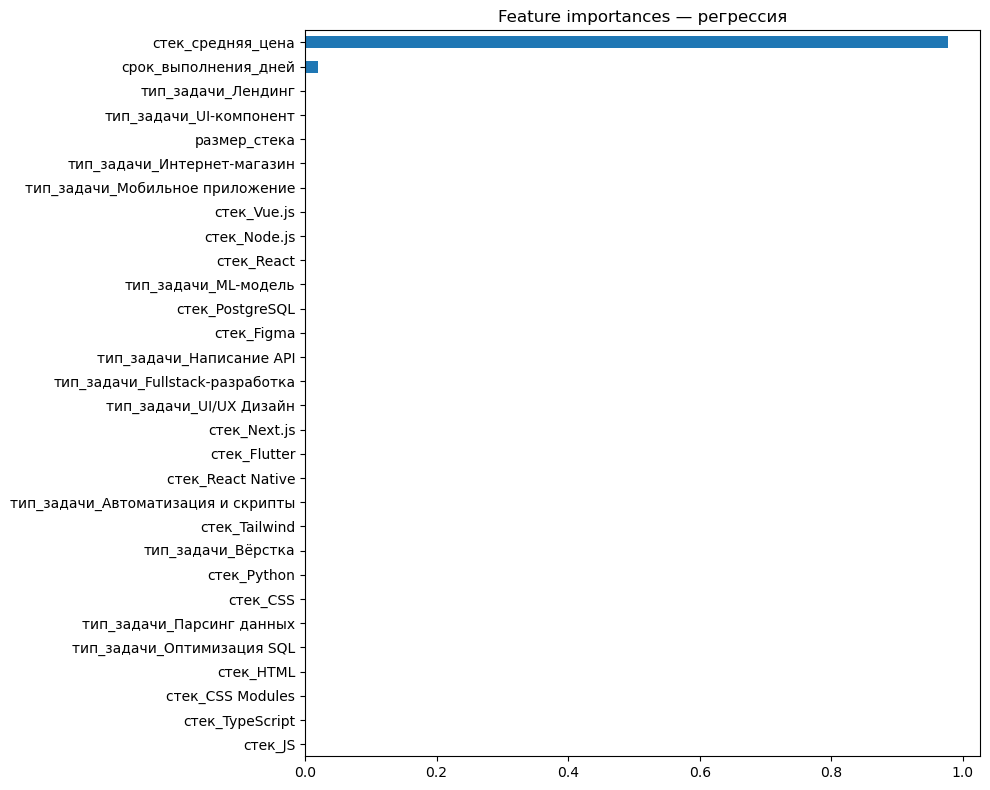

In [103]:
pd.Series(best_gs['RF'].best_estimator_.feature_importances_,
          index=X_train.columns).sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Feature importances — регрессия')
plt.tight_layout()
plt.show()

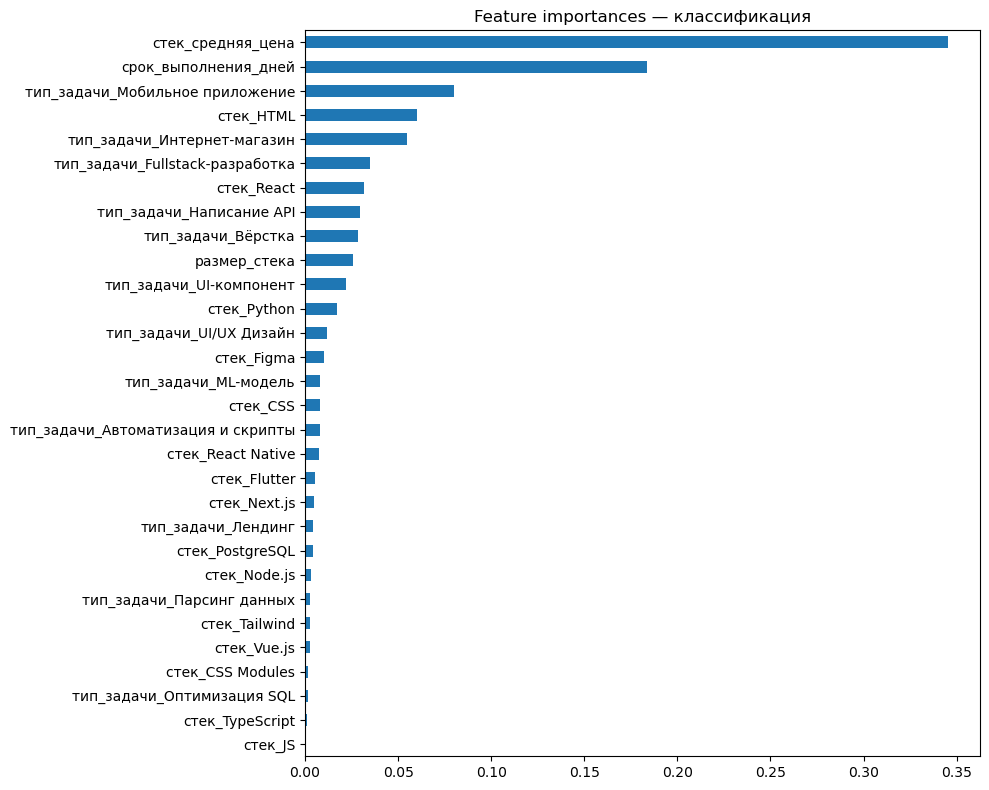

In [104]:
pd.Series(grid_search_cls.best_estimator_.feature_importances_,
          index=X_train_cls.columns).sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Feature importances — классификация')
plt.tight_layout()
plt.show()

Топ-2 признака совпадают в обеих задачах:
- `стек_средняя_цена` — доминирует с большим отрывом
- `срок_выполнения_дней` — стабильно на втором месте

Третий признак различается:
- В регрессии — `тип_задачи_Лендинг`
- В классификации — `тип_задачи_Мобильное приложение`

Это подтверждает выводы EDA: технологический стек и срок выполнения являются 
главными факторами ценообразования на рынке фриланса.

### Сохранение датасета и моделей

In [105]:
# Сохраняем модели
joblib.dump(best_gs['RF'].best_estimator_, 'model_regression.pkl')
joblib.dump(grid_search_cls.best_estimator_, 'model_classification.pkl')

# Сохраняем новый датасет
df_copy.to_csv('dataset_processed.csv', index=False)